# **Exploratory Data Analysis**

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [ ]:
eda_df = pd.read_csv('dataset/cleaned/ecommerce_cleaned.csv')

## **Executive Summary**

### KPIs

In [9]:
# Summary
print(f"Total Transactions      : {len(eda_df):,}")
print(f"Total Revenue           : ${eda_df['total_price_usd'].sum():,.2f}")
print(f"Total Profit            : ${eda_df['profit_usd'].sum():,.2f}")
print(f"Countries Covered       : {eda_df['country'].nunique()}")
print(f"Product Categories      : {eda_df['category'].nunique()}")

# Average Metrics
print(f"Average Order Value     : ${eda_df['total_price_usd'].mean():,.2f}")
print(f"Average Profit Margin   : {eda_df['profit_margin_percent'].mean():.2f}%")
print(f"Average Shipping Cost   : ${eda_df['shipping_cost_usd'].mean():,.2f}")
print(f"Average Delivery Days   : {eda_df['delivery_days'].mean():.2f}")
print(f"Average Loyalty Score   : {eda_df['customer_loyalty_score'].mean():.2f}")
print(f"Average Fraud Score     : {eda_df['fraud_risk_score'].mean():.2f}")

Total Transactions      : 1,000,123
Total Revenue           : $403,285,857.00
Total Profit            : $160,946,812.88


KeyError: 'country'

In [ ]:
# Order
print(f'Total Orders            : {eda_df['order_id'].count()}')
print(f'Total Unique Orders     : {eda_df['order_id'].nunique()}') # Unique

# Customer
print(f'Total Customers         : {eda_df['customer_id'].count()}')
print(f'Total Unique Customers  : {eda_df['customer_id'].nunique()}') # Unique

Total Orders            : 1000123
Total Unique Orders     : 991930
Total Customers         : 1000123
Total Unique Customers  : 991945


> **Data Quality Note**:
> During data validation, `order_id` and `customer_id` were found to contain repeated values associated with different transaction details (e.g., different dates, countries, and customer segments). This indicates that these identifiers are **not consistently unique** across the dataset and therefore cannot be treated as reliable primary keys. Consequently, each row is treated as an independent transaction throughout the analysis.

### **Identify outliers, distribution, and skewed data using Histogram**

#### Format DPI and Theme

In [ ]:
def format_data(title, xtitle, ytitle):
    plt.title(title)
    plt.xlabel(xtitle)
    plt.ylabel(ytitle)
    plt.tight_layout()
    plt.show()

### **Numerical Variables**

#### Continuous Values

In [ ]:
continuous_cols = [
    'unit_price_usd',
    'total_price_usd',
    'profit_usd',
    'shipping_cost_usd',
    'customer_loyalty_score',
    'session_duration_minutes',
    'profit_margin_percent',
    'fraud_risk_score'
]

In [ ]:
# Detect outliers in numeric columns using the IQR rule.
numeric_cols = ecommerce_df.select_dtypes(include='number')

for col in numeric_cols:
    Q1 = ecommerce_df[col].quantile(0.25)
    Q3 = ecommerce_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ecommerce_df[
        (ecommerce_df[col] < lower) |
        (ecommerce_df[col] > upper)
    ]

    count = len(outliers)
    percent = (count / len(ecommerce_df)) * 100

    if round(percent, 2) > 0:
        print(f"{col}: {count:,} outliers")
        print(f"{col} in percent (%) : {percent:.2f}% outliers\n")

NameError: name 'ecommerce_df' is not defined

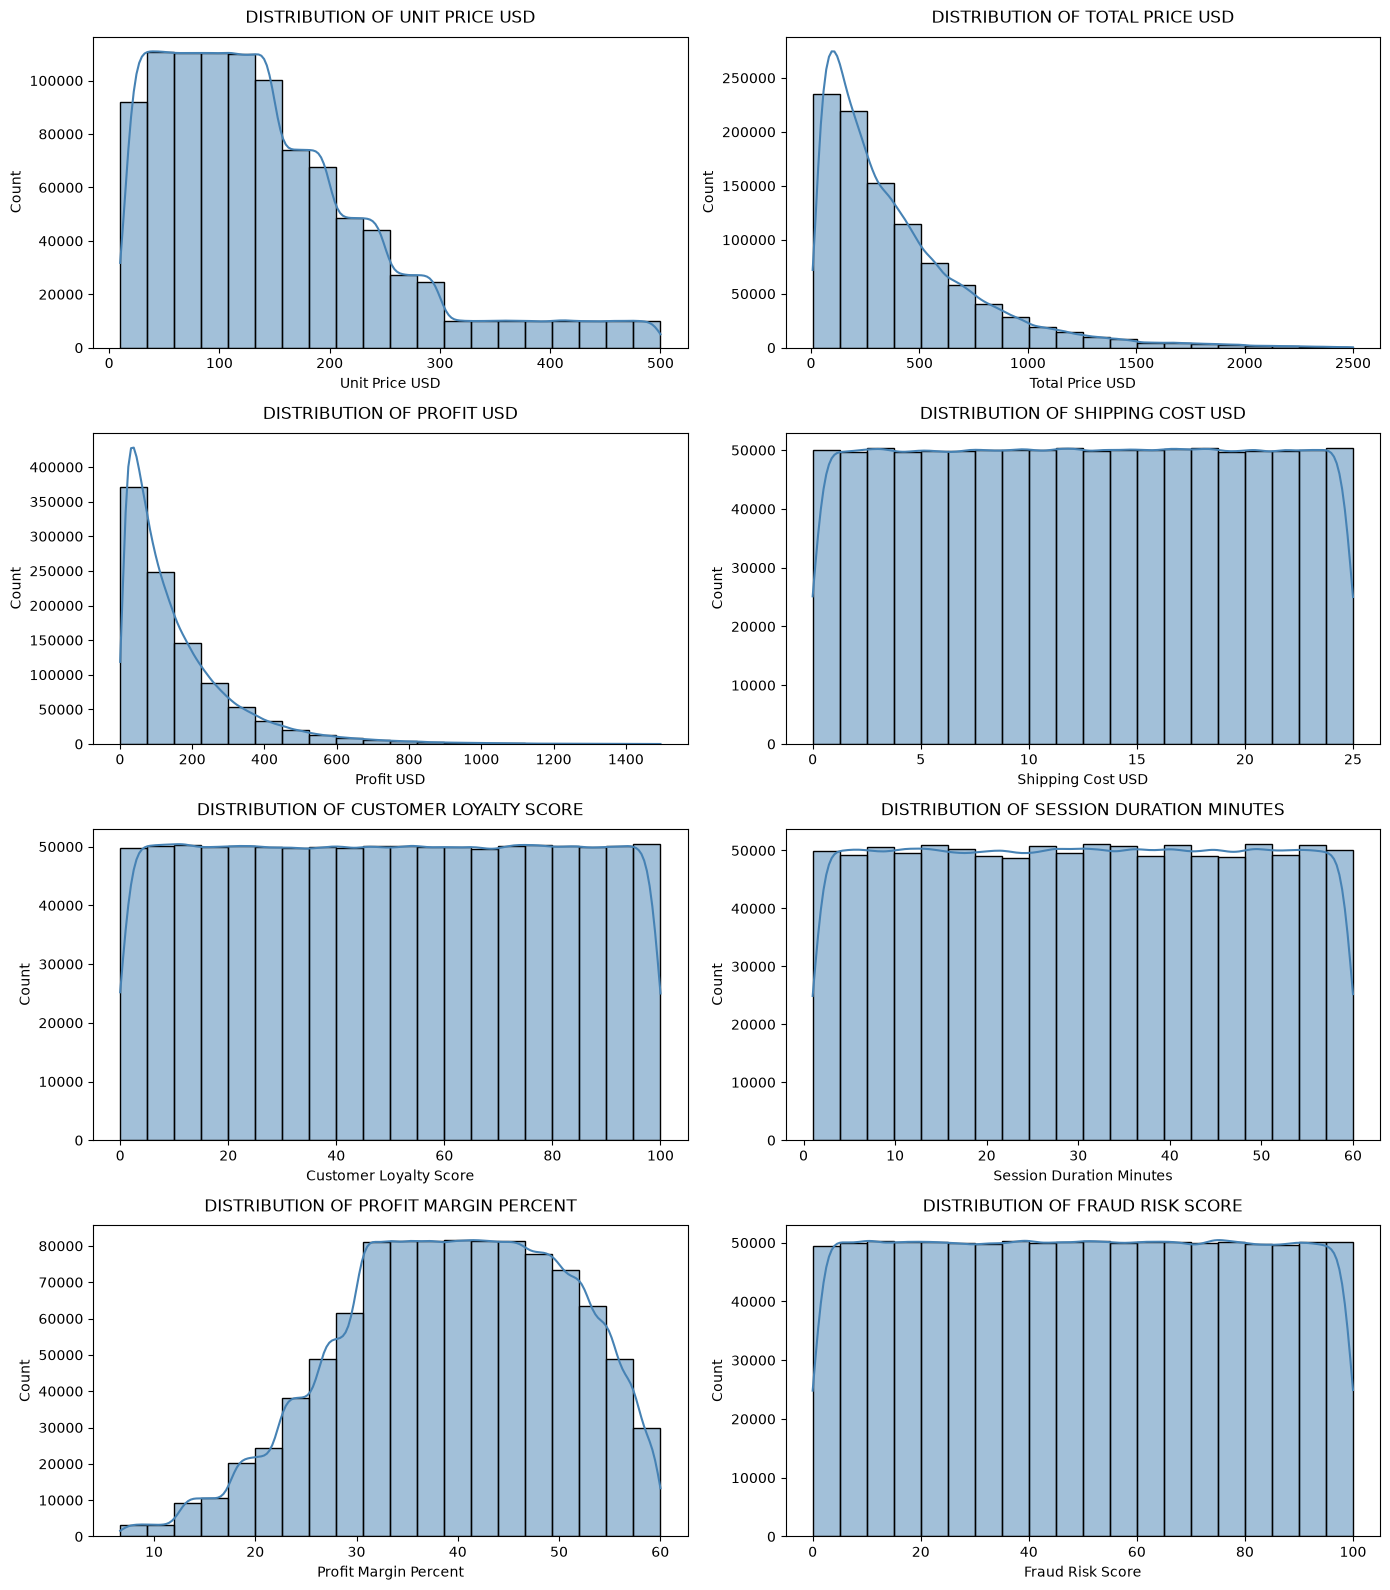

In [ ]:
# Histogram
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  # para madaling i-loop
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.histplot(
        data=eda_df,
        x=cons,
        bins=20,
        ax=ax,
        color='steelblue',
        kde=True
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

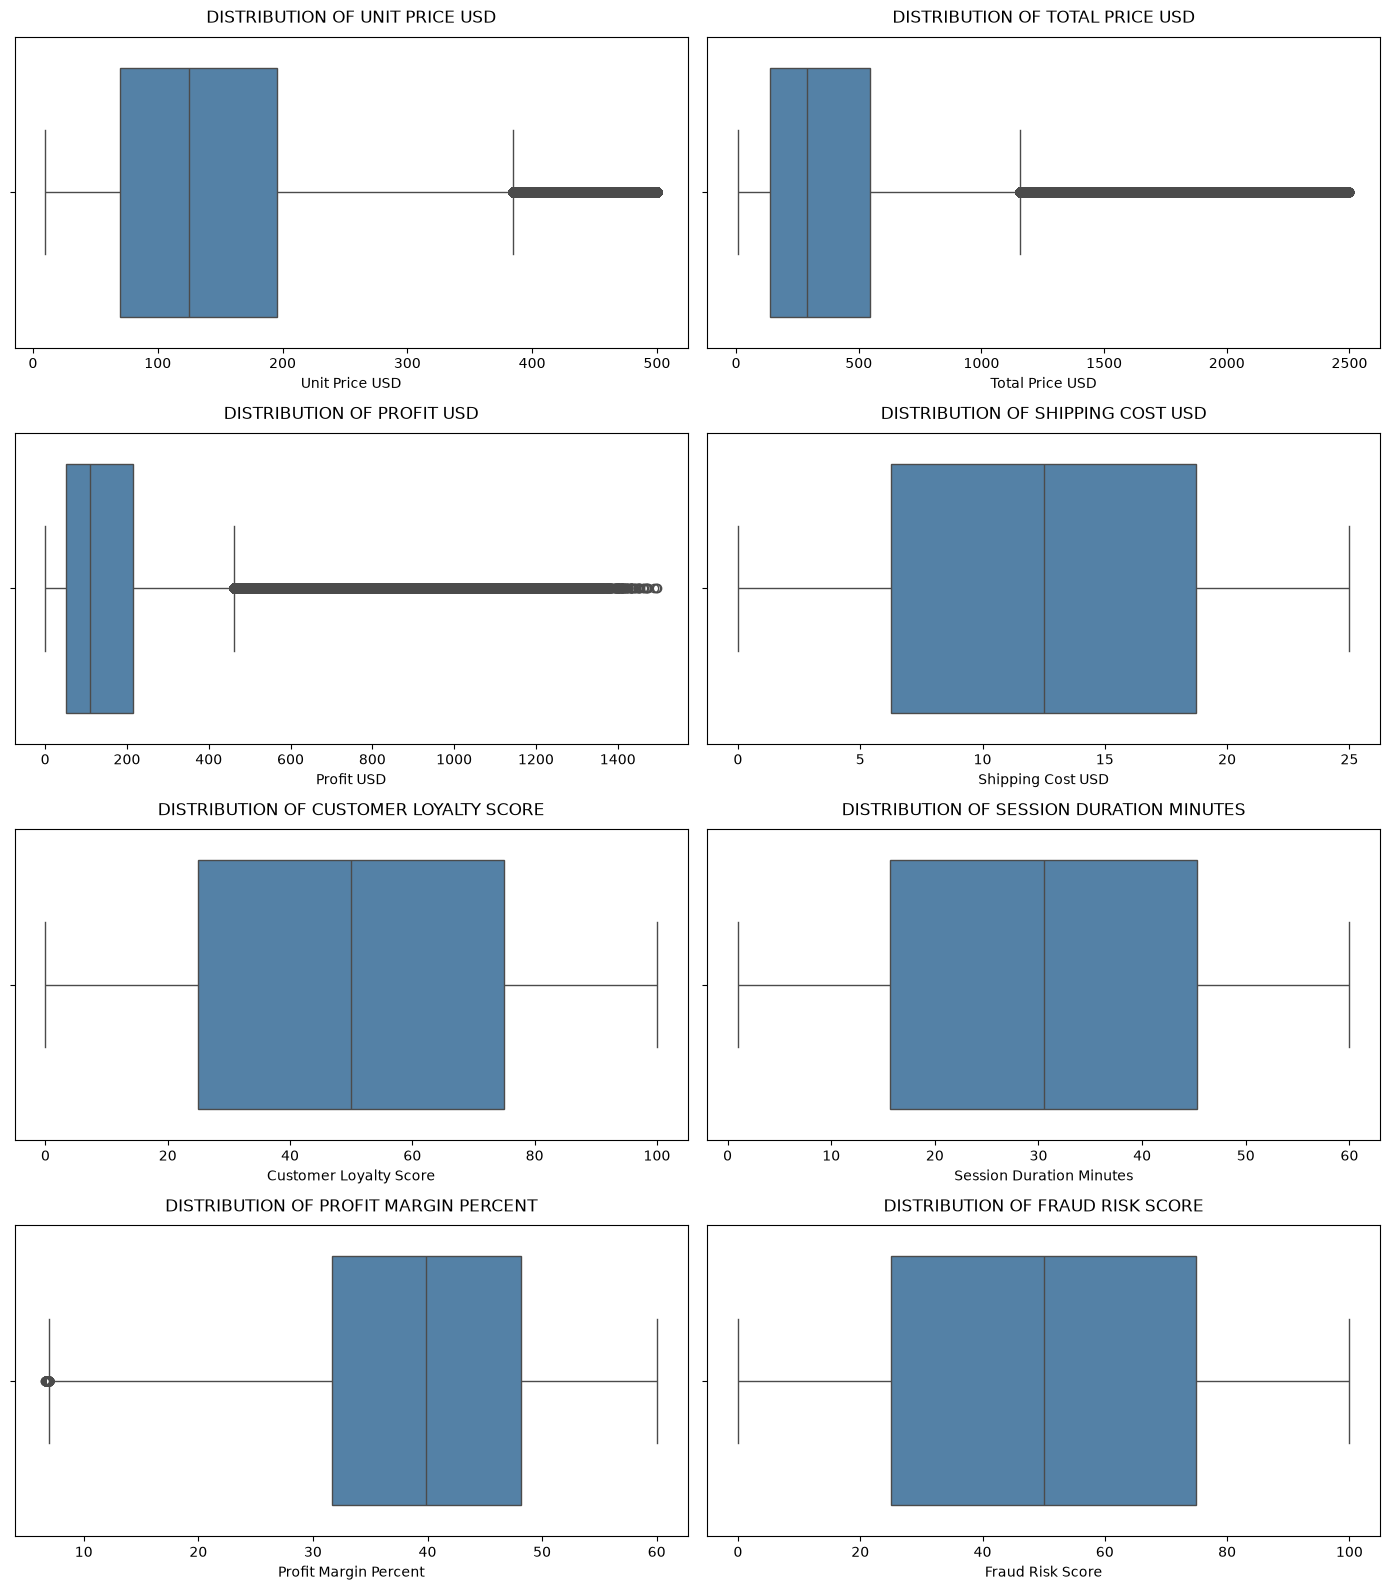

In [ ]:
# Boxplot
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()  # para madaling i-loop
for i, cons in enumerate(continuous_cols):
    ax = axes[i]
    
    sns.boxplot(
        data=eda_df,
        x=cons,
        ax=ax,
        color='steelblue'
    )
    
    # Title & labels
    title = f'Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)

# Hide empty subplots (kung hindi exact multiple of 2)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

The primary skewness and outlier patterns are observed in the monetary variables **``(unit_price_usd, total_price_usd, and profit_usd)``**. Although these variables exhibit noticeable right-skewness and contain outliers, the values appear to be valid and reflect genuine business transactions rather than data quality issues. In contrast, the remaining numerical features are more evenly distributed and show relatively few extreme values. Overall, the skewness and outliers in the monetary metrics should be treated as meaningful business observations rather than noise.

#### Discrete Values

In [ ]:
discrete_cols = [

    # Count Variables
    "quantity",
    "delivery_days",

    # Calendar Variables
    "order_year",
    "order_month",
    "order_day",
    "part_day",
    "is_weekend"

]

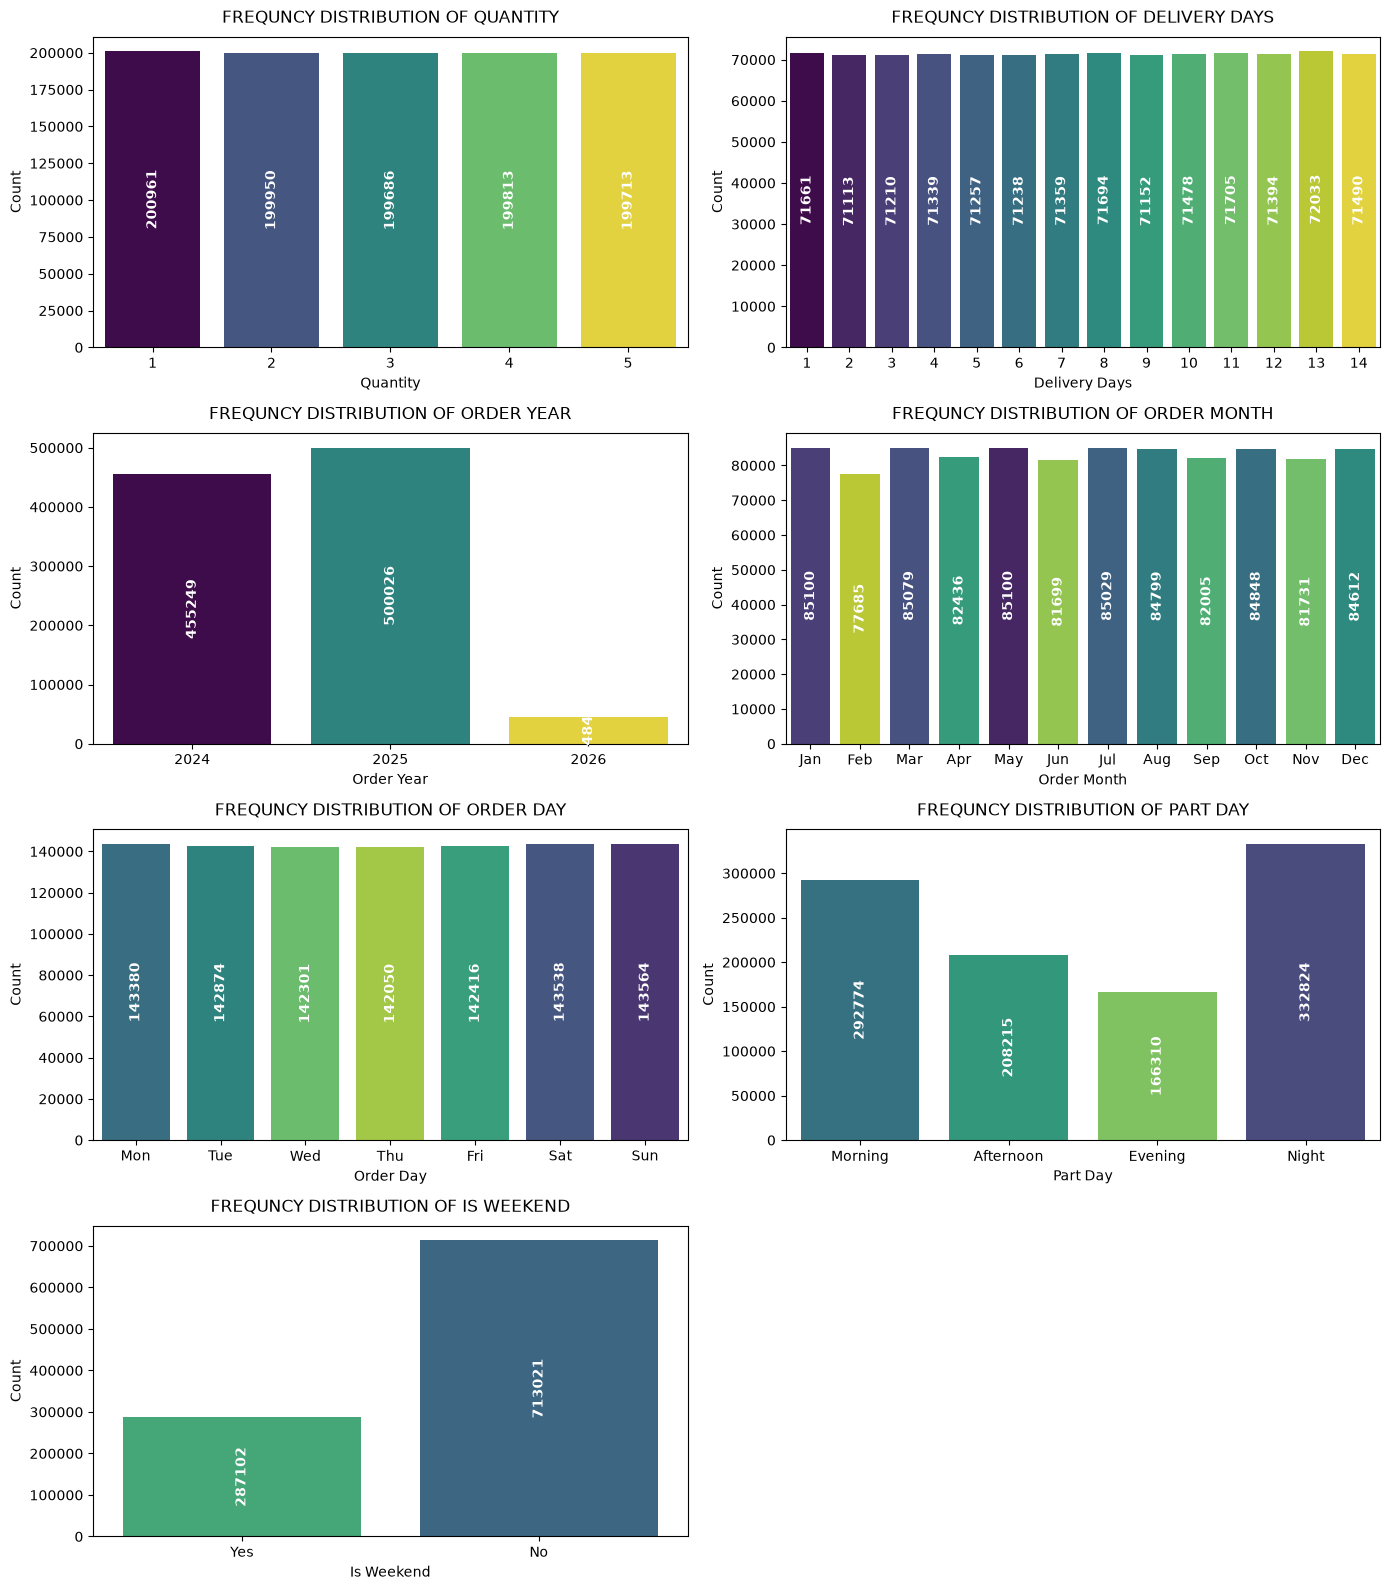

In [ ]:
# Bar Chart

# Custom order for column that has natural sequence
custom_order = {
    'order_day': ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
    'part_day': ['Morning', 'Afternoon', 'Evening', 'Night'],
    'order_month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'is_weekend' : ['Yes', 'No']
}

n_cols = 2
n_rows = math.ceil(len(discrete_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, cons in enumerate(discrete_cols):
    ax = axes[i]
    
    count_discrete = eda_df[cons].value_counts().reset_index()
    count_discrete.columns = [cons, 'count']
    
    # Use custom order if available, otherwise 
    order = custom_order.get(cons, count_discrete[cons].sort_values(ascending=True))
    
    sns.barplot(
        data=count_discrete,
        x=cons,
        y='count',
        order=order,       
        ax=ax,
        palette='viridis',
        hue=cons,
        legend=False
    )
    
    title = f'Frequncy Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%d',
            label_type='center',
            color='white',
            rotation=90,
            weight='bold'
        )
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical Values

In [ ]:
categorical_cols= [

    "country",
    "category",
    "customer_segment"

]

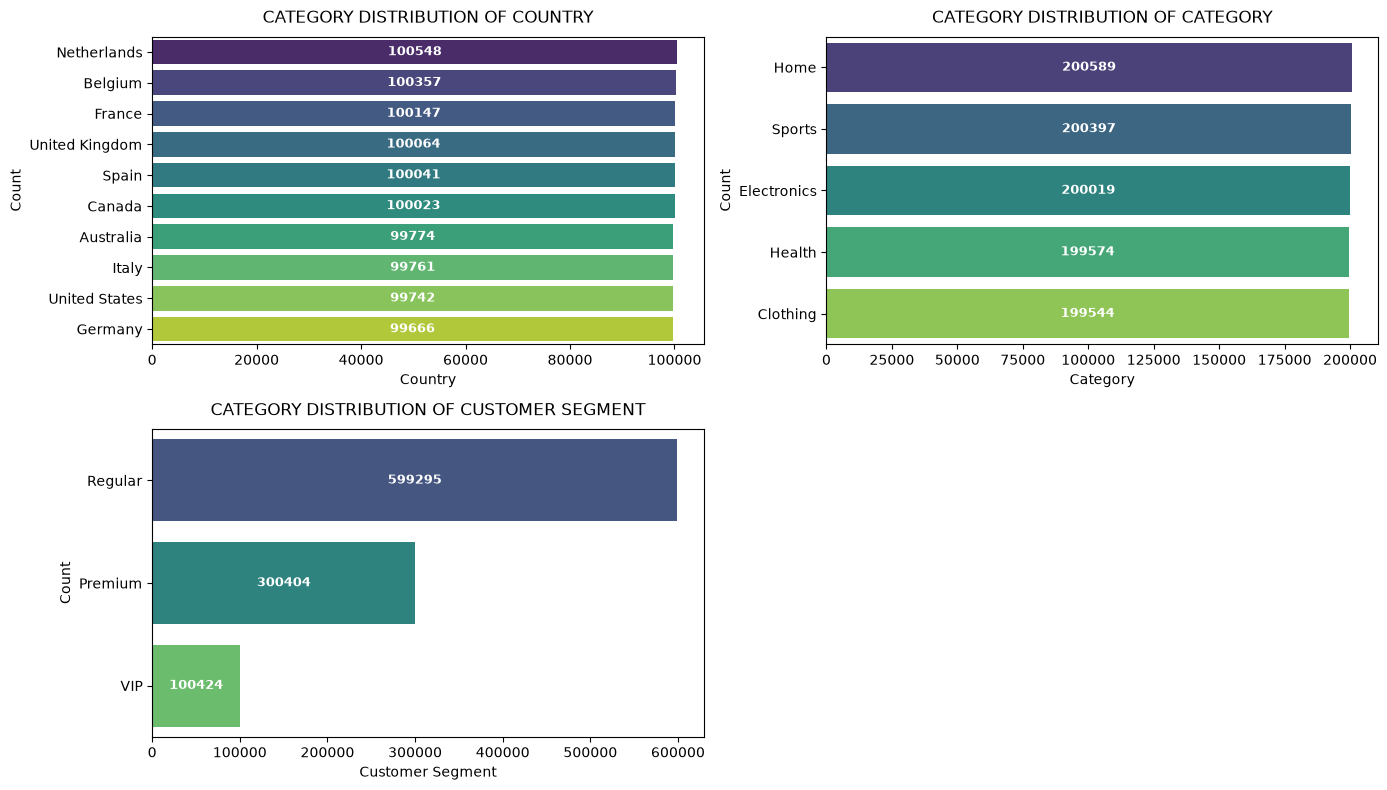

In [ ]:
# Horizontal Chart

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

for i, cons in enumerate(categorical_cols):
    ax = axes[i]
    
    count_discrete = eda_df[cons].value_counts().reset_index()
    count_discrete.columns = [cons, 'count']
    
    # Use custom order if available, otherwise 
    order = custom_order.get(cons, count_discrete[cons].sort_values(ascending=True))
    
    sns.barplot(
        data=count_discrete,
        x='count',
        y=cons,      
        ax=ax,
        palette='viridis',
        hue=cons,
        legend=False
    )
    
    title = f'Category Distribution of {cons.replace("_", " ")}'.upper()
    xlabel = cons.replace('_', ' ').title().replace('Usd', 'USD')
    
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%d',
            fontsize=9,
            label_type='center',
            color='white',
            fontweight='bold'
        )
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    
# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

### Correlation Analysis

In [ ]:
corr_cols = [
    "customer_loyalty_score",
    "session_duration_minutes",
    "shipping_cost_usd",
    "delivery_days",
    "fraud_risk_score",
    "quantity"
]

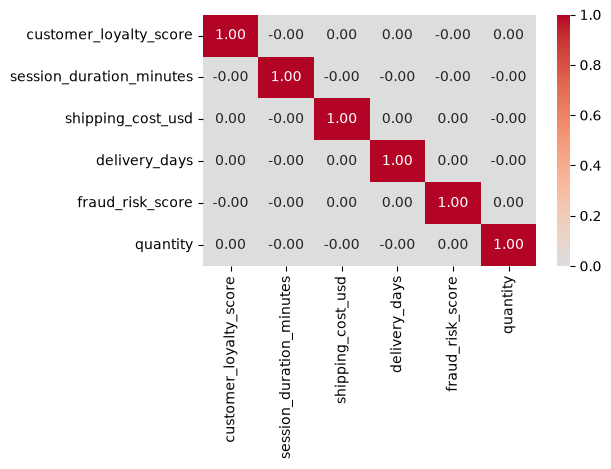

In [ ]:
eda_numeric_cols = eda_df.select_dtypes(include='number').columns.tolist()

sns.heatmap(
    eda_df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.tight_layout(pad=1.09)
plt.show()

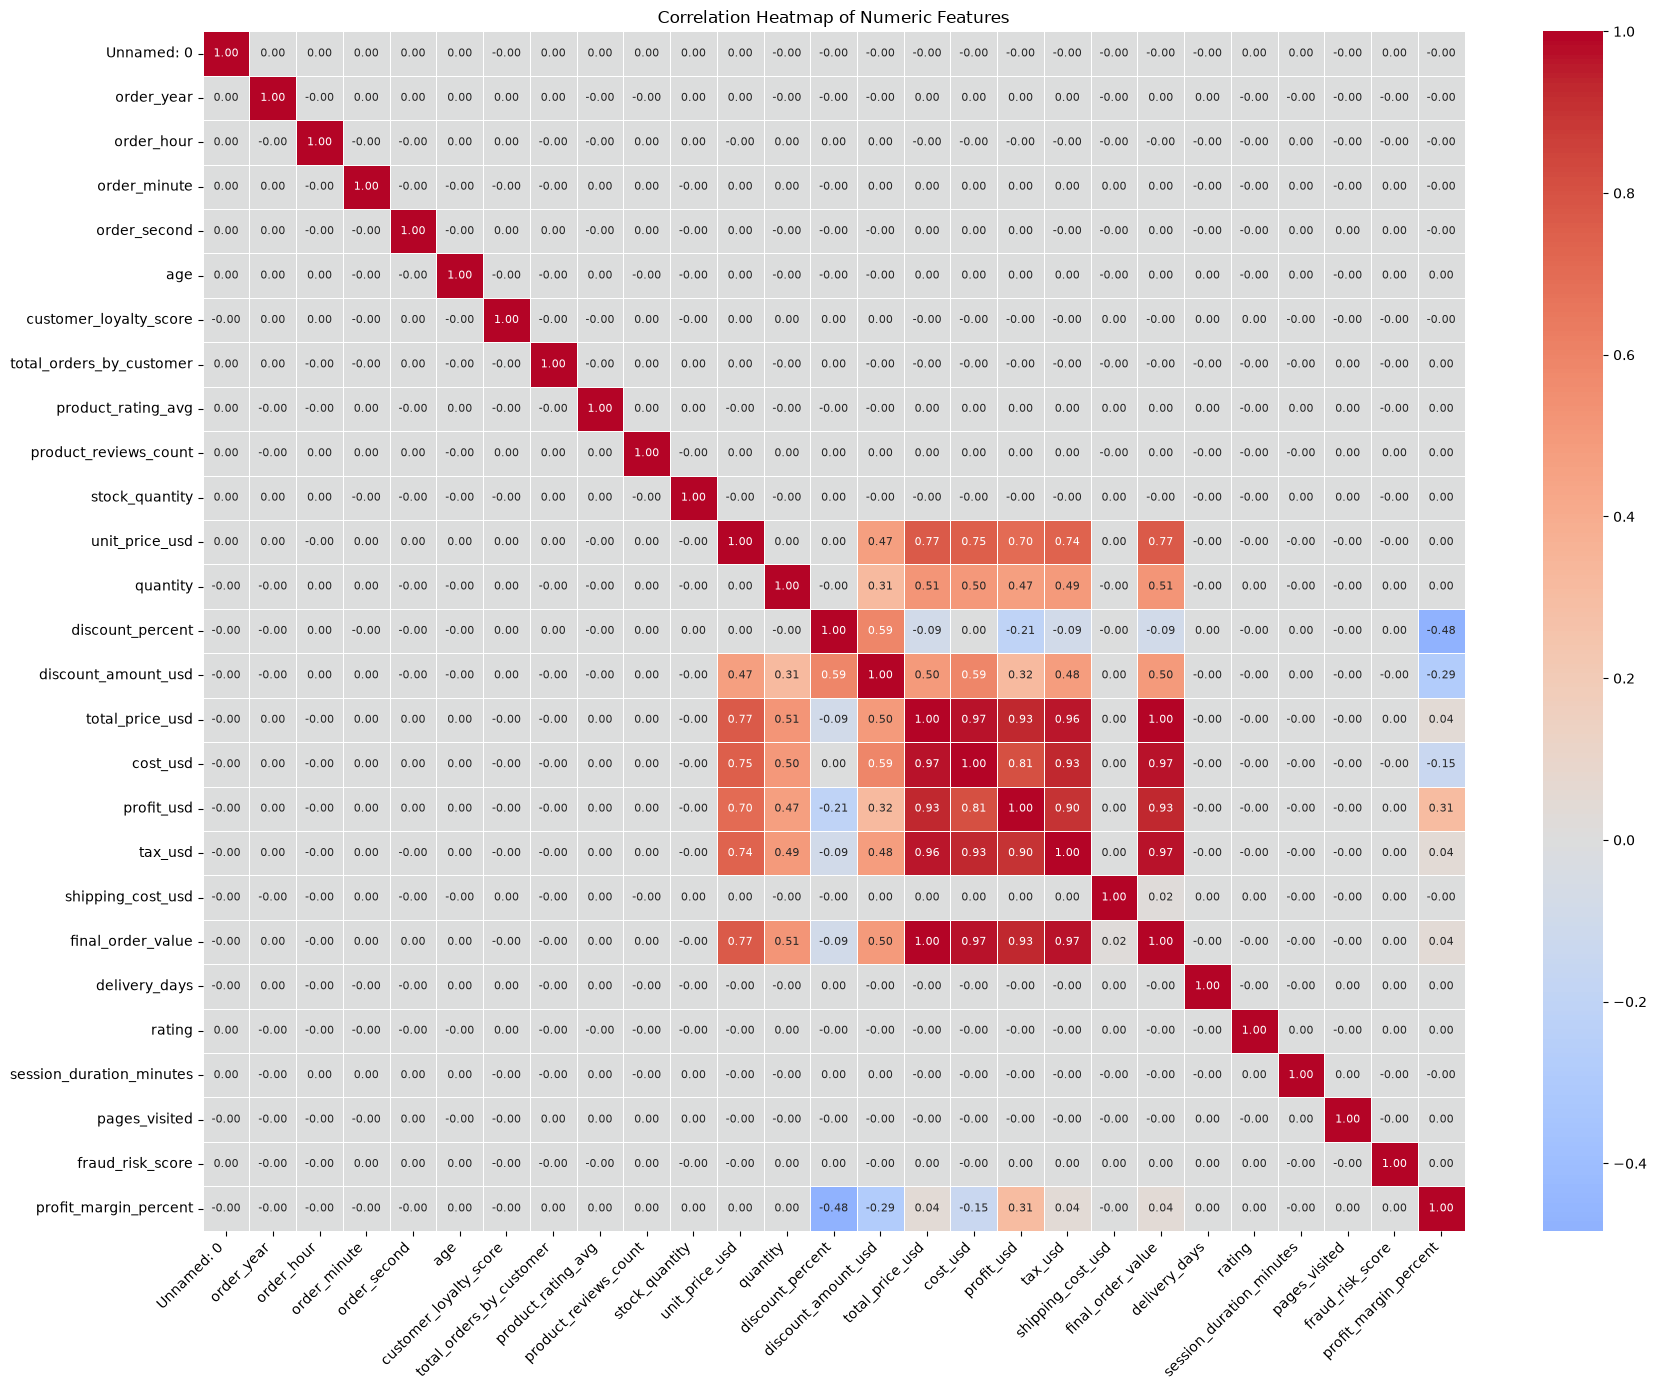

In [ ]:
eda_numeric_cols = ecommerce_df.select_dtypes(include='number')

plt.figure(figsize=(18, 14))  # mas malaki

sns.heatmap(
    eda_numeric_cols.corr(),
    annot=True,
    fmt='.2f',                    # 2 decimal places
    cmap='coolwarm',
    center=0,
    annot_kws={'size': 8},        # ← paliitin ang font ng numbers
    linewidths=0.5,
    linecolor='white'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()